### Подключение Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Импорт библиотек

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os

### Путь к датасету

In [ ]:
dataset_path = "/content/drive/MyDrive/ML/Data"

### Основные параметры

In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

### Загрузка train и validation

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 8917 files belonging to 3 classes.
Using 7134 files for training.
Found 8917 files belonging to 3 classes.
Using 1783 files for validation.


### Проверка названий классов

In [ ]:
class_names = train_dataset.class_names
num_classes = len(class_names)

print("Классы:", class_names)
print("Количество классов:", num_classes)

Классы: ['anime', 'cartoon', 'human']
Количество классов: 3


### Визуализация нескольких изображений

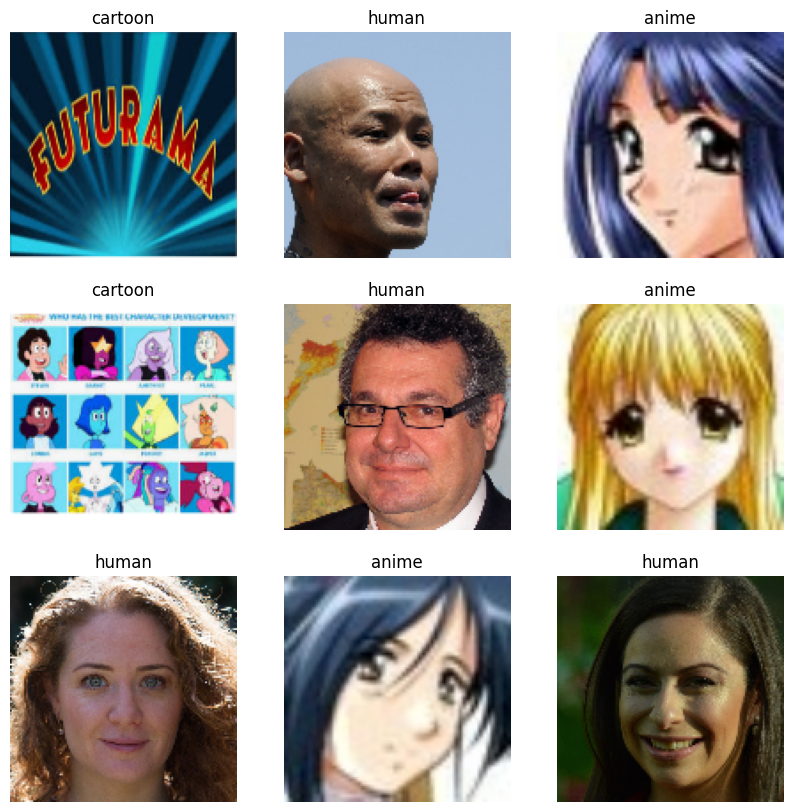

In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

### Аугментация данных

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

### Нормализация

In [ ]:
normalization_layer = layers.Rescaling(1.0 / 255)

### Применение предобработки

In [ ]:
train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(data_augmentation(x, training=True)), y),
    num_parallel_calls=AUTOTUNE
)

val_dataset = val_dataset.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

### Ускорение загрузки

In [ ]:
train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)

### Построение первой CNN с нуля

* 3 сверточных блока
* max pooling
* dropout
* полносвязный слой
* softmax на 3 класса



In [ ]:
model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

### Компиляция модели

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Просмотр архитектуры

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,067 (16.36 MB)

 Trainable params: 4,288,067 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

### Методы регуляризации обучения

* EarlyStopping — остановит обучение, если модель перестала улучшаться
* ModelCheckpoint — сохранит лучшую модель

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='best_cnn_model.keras',
        monitor='val_loss',
        save_best_only=True
    )
]

### Обучение модели

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 910s 4s/step - accuracy: 0.8695 - loss: 0.3217 - val_accuracy: 0.9770 - val_loss: 0.0627
Epoch 2/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 500s 2s/step - accuracy: 0.9680 - loss: 0.0937 - val_accuracy: 0.9860 - val_loss: 0.0405
Epoch 3/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 510s 2s/step - accuracy: 0.9762 - loss: 0.0711 - val_accuracy: 0.9921 - val_loss: 0.0237
Epoch 4/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 496s 2s/step - accuracy: 0.9801 - loss: 0.0565 - val_accuracy: 0.9860 - val_loss: 0.0357
Epoch 5/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 517s 2s/step - accuracy: 0.9868 - loss: 0.0438 - val_accuracy: 0.9905 - val_loss: 0.0218
Epoch 6/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 581s 2s/step - accuracy: 0.9854 - loss: 0.0466 - val_accuracy: 0.9966 - val_loss: 0.0069
Epoch 7/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 512s 2s/step - accuracy: 0.9905 - loss: 0.0337 - val_accuracy: 0.9972 - val_loss: 0.0057
Epoch 8/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 497s 2s/step - accuracy: 0.9882 - loss: 0.0374 - val_accu

### Оценка качества модели

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, f1_score
import pandas as pd
from sklearn.metrics import classification_report

y_true = []
y_pred = []
y_prob = []

for images, labels in val_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)
    y_prob.extend(predictions)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("Размер y_true:", y_true.shape)
print("Размер y_pred:", y_pred.shape)

accuracy = accuracy_score(y_true, y_pred)
recall_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')

recall_weighted = recall_score(y_true, y_pred, average='weighted')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Recall (macro): {recall_macro:.4f}")
print(f"F1-score (macro): {f1_macro:.4f}")
print(f"Recall (weighted): {recall_weighted:.4f}")
print(f"F1-score (weighted): {f1_weighted:.4f}")

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
print(report_df)

Размер y_true: (1783,)
Размер y_pred: (1783,)
Accuracy: 0.9972
Recall (macro): 0.9972
F1-score (macro): 0.9972
Recall (weighted): 0.9972
F1-score (weighted): 0.9972
              precision    recall  f1-score      support
anime          0.998333  0.998333  0.998333   600.000000
cartoon        1.000000  0.994889  0.997438   587.000000
human          0.993322  0.998322  0.995816   596.000000
accuracy       0.997196  0.997196  0.997196     0.997196
macro avg      0.997219  0.997182  0.997196  1783.000000
weighted avg   0.997207  0.997196  0.997197  1783.000000


### Графики обучения

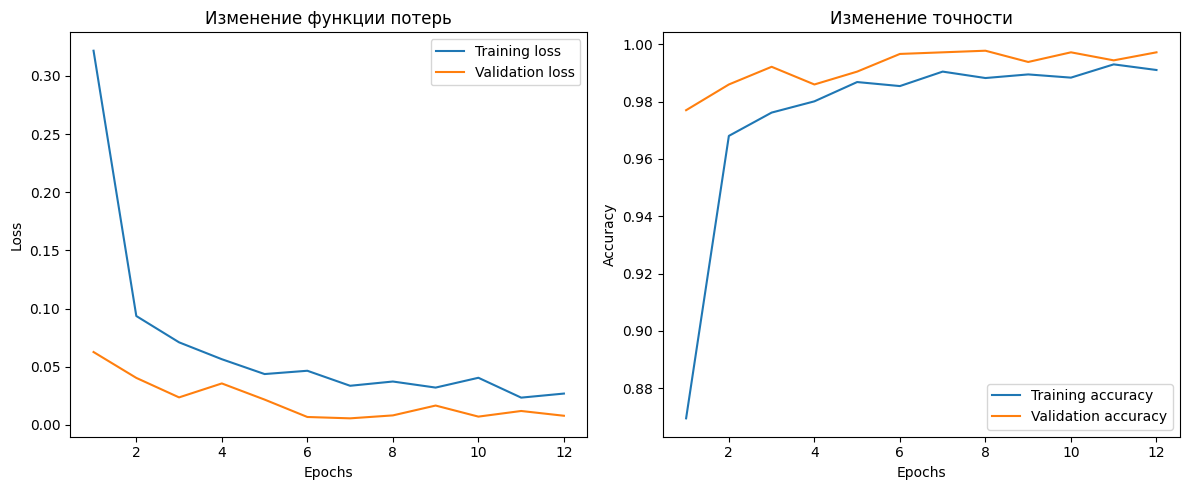

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label='Training loss')
plt.plot(epochs_range, val_loss, label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Изменение функции потерь')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, label='Training accuracy')
plt.plot(epochs_range, val_acc, label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Изменение точности')
plt.legend()

plt.tight_layout()
plt.show()

### Матрица ошибок

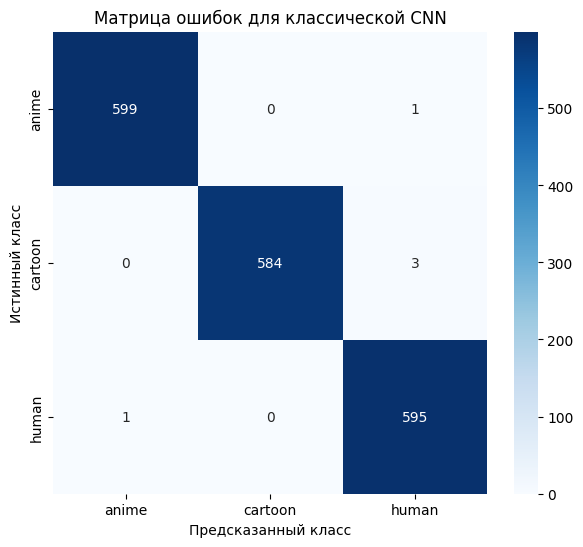

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок для классической CNN')
plt.show()

### График метрик качества

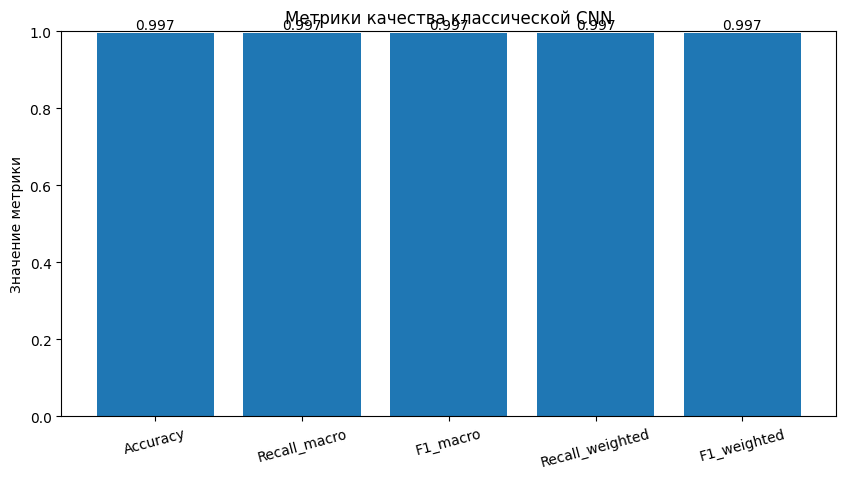

In [ ]:
metrics_names = ['Accuracy', 'Recall_macro', 'F1_macro', 'Recall_weighted', 'F1_weighted']
metrics_values = [accuracy, recall_macro, f1_macro, recall_weighted, f1_weighted]

plt.figure(figsize=(10, 5))
bars = plt.bar(metrics_names, metrics_values)
plt.ylim(0, 1)
plt.ylabel('Значение метрики')
plt.title('Метрики качества классической CNN')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f'{height:.3f}', ha='center')

plt.xticks(rotation=15)
plt.show()